In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report

import time
from datetime import datetime, timedelta
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [6]:
import os 
os.getcwd()
os.listdir()


['Untitled.ipynb',
 'training_data_imputed_simple_full_BACKUP.csv.gz',
 'slurmsession_train_surv.sh',
 'training_data_imputed_simple_TRAIN_BACKUP.csv.gz',
 'training_data_30d.csv',
 'training_data_imputed_simple_TRAIN.csv.gz',
 'google_cloud_sql',
 'liver_labs.csv',
 'training_data_imputed_simple_full.csv.gz',
 'mimic-demo',
 'elisa_7d_model.json',
 'LICENSE',
 '.Rprofile',
 'icd9_2d_model.json',
 'elisa_2d_model.json',
 '7d_best_model.json',
 'training_data_imputed_simple_TEST.csv.gz',
 'impute_missing_data_test.ipynb',
 '.ipynb_checkpoints',
 'model_dev_fullset.ipynb',
 'slurmsession_train.sh',
 'unimpute_30d_best_model.json',
 'model_final_tests.ipynb',
 'icd9_7d_model.json',
 'random_survival_forests.ipynb',
 'create_training_data_fullset.r',
 'training_data_1d.csv',
 'impute_missing_data_fullset.py',
 'slurmsession_clean.sh',
 '2025-05-24_16_41_rsf_bestmodel.joblib.gz',
 'UNIMPUTED_model_dev_fullset.ipynb',
 'training_data_7d.csv',
 '.Rhistory',
 'launch_jupyterlab.sh',
 'training

In [8]:
training_data_unimputed_df = pd.read_csv("training_data_full.csv.gz") 

In [9]:
training_data_unimputed_df.head()
training_data_unimputed_df.shape

(112900, 176)

In [10]:
train_df, val_df = train_test_split(training_data_unimputed_df, test_size=0.2, random_state=1)

In [7]:
val_df

,ab_class_is_Fluoroquinolone,ab_class_is_Lincosamide,ab_class_is_Nitroimidazole,ab_class_is_Carbapenem,ab_class_is_Aminoglycoside,ab_class_is_Glycopeptide,ab_class_is_Cephalosporin,ab_class_is_Oxazolidinone,ab_class_is_Macrolide,ab_class_is_Lipopeptide,...,cdiff_7d_flag,cdiff_30d_flag,cdiff_survival_flag,survival_time,cdiff_label_elisa_2d,cdiff_label_elisa_7d,cdiff_label_elisa_30d,cdiff_label_icd9_2d,cdiff_label_icd9_7d,cdiff_label_icd9_30d
39922,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1.564583,NaN,NaN,NaN,NaN,NaN,NaN
53792,0,0,0,0,0,0,0,0,0,0,...,0,0,0,18.708333,NaN,NaN,NaN,0.0,0.0,NaN
38161,0,0,1,0,0,0,0,0,0,0,...,0,0,0,7.599306,NaN,NaN,NaN,0.0,0.0,NaN
73453,0,0,0,0,0,0,0,0,0,0,...,0,0,0,29.511111,NaN,NaN,NaN,0.0,0.0,NaN
90056,0,0,0,1,0,0,0,0,0,0,...,0,0,0,41.562500,NaN,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104474,0,0,0,0,0,1,0,0,0,0,...,0,0,0,4.541667,NaN,NaN,NaN,0.0,NaN,NaN
1928,0,0,0,0,0,0,0,0,0,0,...,0,0,0,23.729167,NaN,NaN,NaN,0.0,0.0,NaN
47835,0,0,0,0,0,0,0,0,0,0,...,0,0,0,47.697917,NaN,NaN,NaN,0.0,0.0,0.0
61053,0,0,0,0,0,1,0,0,0,0,...,0,0,0,4.736111,NaN,NaN,NaN,0.0,NaN,NaN


In [13]:
cols_drop = (['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time', 'cdiff_label_elisa_2d', 'cdiff_label_elisa_7d', 'cdiff_label_elisa_30d',
    'cdiff_label_icd9_2d', 'cdiff_label_icd9_7d', 'cdiff_label_icd9_30d',
    'cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag',
    'survival_time', 'cdiff_survival_flag'])

X = train_df.drop(columns=cols_drop, axis=1)
print(X.columns.tolist())


['ab_class_is_Fluoroquinolone', 'ab_class_is_Lincosamide', 'ab_class_is_Nitroimidazole', 'ab_class_is_Carbapenem', 'ab_class_is_Aminoglycoside', 'ab_class_is_Glycopeptide', 'ab_class_is_Cephalosporin', 'ab_class_is_Oxazolidinone', 'ab_class_is_Macrolide', 'ab_class_is_Lipopeptide', 'ab_class_is_Monobactam', 'ab_class_is_Penicillin', 'ab_class_is_Glycylcycline', 'ab_class_is_Sulfonamide', 'ab_class_is_Polymyxin', 'ab_class_is_Nitrofuran', 'ab_class_is_Tetracycline', 'is_female', 'admit_is_EMERGENCY', 'admit_is_ELECTIVE', 'admit_is_NEWBORN', 'admit_is_URGENT', 'mean_aspartate_aminotransferase', 'mean_bilirubin_total', 'mean_alanine_transaminase', 'mean_alkaline_phosphatase', 'mean_gamma_glutamyltransferase', 'median_aspartate_aminotransferase', 'median_bilirubin_total', 'median_alanine_transaminase', 'median_alkaline_phosphatase', 'median_gamma_glutamyltransferase', 'max_aspartate_aminotransferase', 'max_bilirubin_total', 'max_alanine_transaminase', 'max_alkaline_phosphatase', 'max_gamma

## Sensitivity Analysis 
For 30 days 

In [9]:
y_30 = train_df['cdiff_30d_flag']

In [10]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_30 == 0).sum()
pos = (y_30 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [11]:
neg = (y_30 == 0).sum()
pos = (y_30 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


Negative: 84879, Positive: 5441, Ratio: 15.60


In [12]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_30)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

Training started at: 2025-05-27 20:45:11
Starting GridSearchCV to find optimal parameters...
Fitting 4 folds for each of 32 candidates, totalling 128 fits

Best parameters found:
{'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 150}
Best cross-validation roc_auc score: 0.9190
Training finished at: 2025-05-27 20:57:00
Total training time: 0:11:48.809774


In [13]:
XGB_model_30 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_30.fit(X, y_30)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [14]:
#X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
X_val = val_df.drop(columns=cols_drop, axis=1)
y_val_30 = val_df['cdiff_30d_flag']

y_val_30.value_counts()

cdiff_30d_flag
0    21158
1     1422
Name: count, dtype: int64

In [15]:
y_val_pred_30 = XGB_model_30.predict(X_val)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_30, y_val_pred_30, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_30, y_score=y_val_pred_30):.4}")


Classification Report:
              precision    recall  f1-score   support

   non-cdiff       0.97      1.00      0.99     21158
       cdiff       0.98      0.60      0.74      1422

    accuracy                           0.97     22580
   macro avg       0.98      0.80      0.86     22580
weighted avg       0.97      0.97      0.97     22580

ROC AUC: 0.7982


<Figure size 1200x800 with 0 Axes>

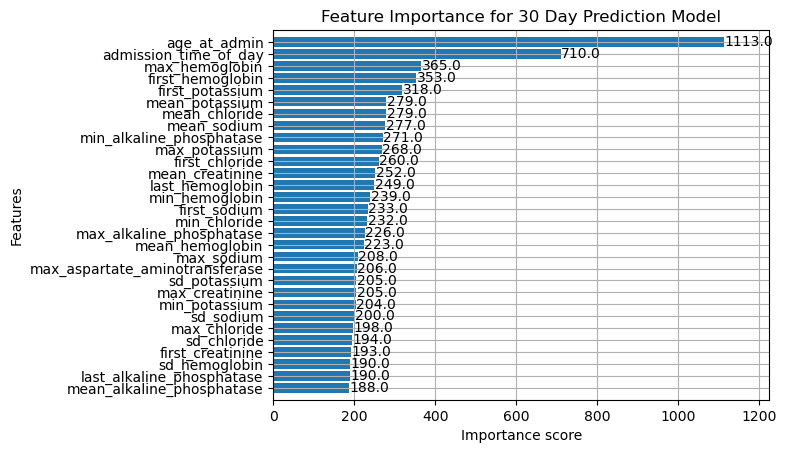

In [16]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_30, max_num_features=30, height=0.8)
plt.title('Feature Importance for 30 Day Prediction Model')
plt.show()

In [17]:
XGB_model_30.save_model('unimpute_30d_best_model.json')

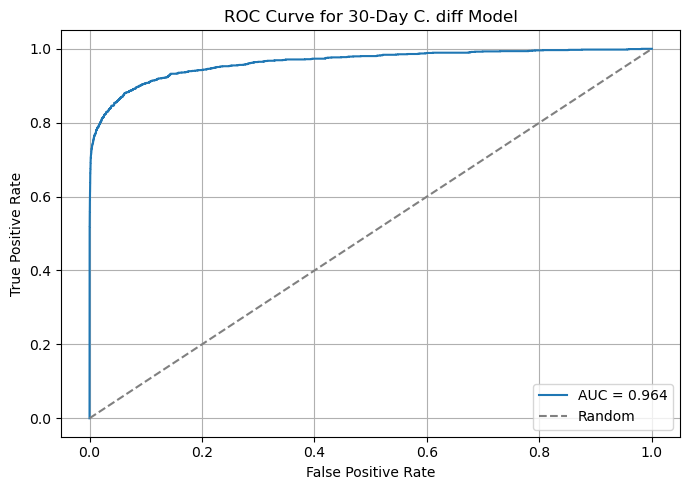

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_30 = val_df["cdiff_30d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_30, y_val_prob_30)
auc_score = roc_auc_score(y_val_30, y_val_prob_30)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 30-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


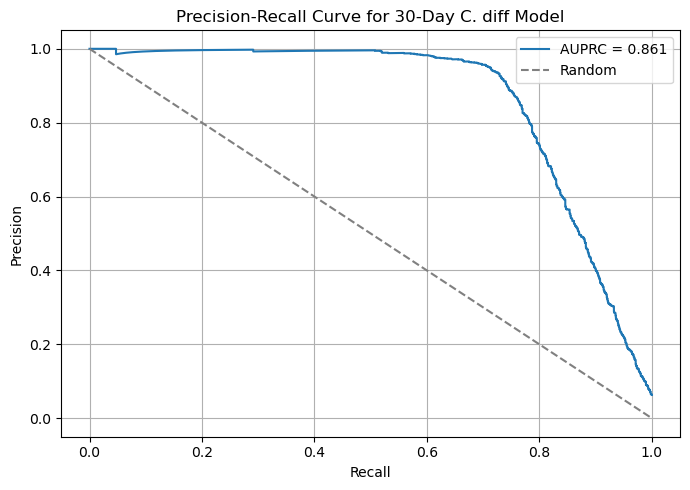

In [19]:


# Ground truth labels
y_val_30 = val_df["cdiff_30d_flag"]

# Predicted probabilities (positive class)
y_val_prob_30 = XGB_model_30.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_30, y_val_prob_30)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_30, y_val_prob_30)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 30-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



For 7 days  

In [20]:
y_7 = train_df['cdiff_7d_flag']

In [21]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_7 == 0).sum()
pos = (y_7 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [22]:
neg = (y_7 == 0).sum()
pos = (y_7 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


Negative: 88012, Positive: 2308, Ratio: 38.13


In [23]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_7)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

Training started at: 2025-05-27 20:57:16
Starting GridSearchCV to find optimal parameters...
Fitting 4 folds for each of 32 candidates, totalling 128 fits

Best parameters found:
{'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 150}
Best cross-validation roc_auc score: 0.8773
Training finished at: 2025-05-27 21:08:11
Total training time: 0:10:55.365723


In [24]:
XGB_model_7 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_7.fit(X, y_7)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [25]:
#X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
X_val = val_df.drop(columns=cols_drop, axis=1)
y_val_7 = val_df['cdiff_7d_flag']

y_val_7.value_counts()

cdiff_7d_flag
0    21996
1      584
Name: count, dtype: int64

In [26]:
y_val_pred_7 = XGB_model_7.predict(X_val)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_7, y_val_pred_7, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_7, y_score=y_val_pred_7):.4}")


Classification Report:
              precision    recall  f1-score   support

   non-cdiff       0.99      1.00      0.99     21996
       cdiff       0.91      0.51      0.65       584

    accuracy                           0.99     22580
   macro avg       0.95      0.75      0.82     22580
weighted avg       0.99      0.99      0.98     22580

ROC AUC: 0.7545


In [27]:
XGB_model_7.save_model('unimpute_7d_best_model.json')

<Figure size 1200x800 with 0 Axes>

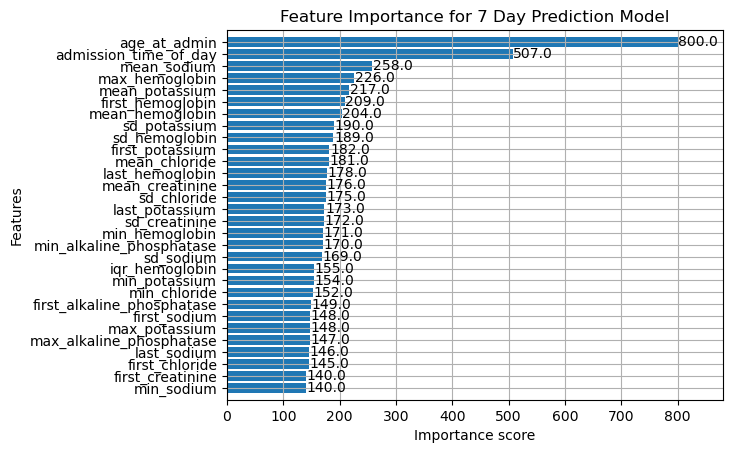

In [28]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_7, max_num_features=30, height=0.8)
plt.title('Feature Importance for 7 Day Prediction Model') 
plt.show()

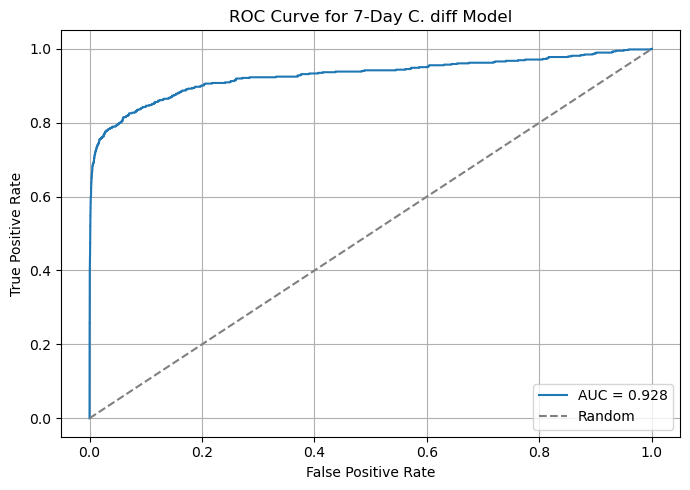

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_7 = val_df["cdiff_7d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_7, y_val_prob_7)
auc_score = roc_auc_score(y_val_7, y_val_prob_7)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 7-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

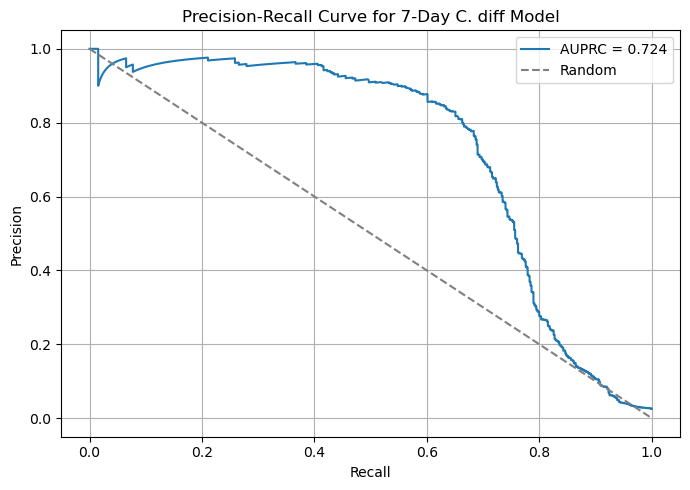

In [31]:
# Ground truth labels
y_val_7 = val_df["cdiff_7d_flag"]

# Predicted probabilities (positive class)
y_val_prob_7 = XGB_model_7.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_7, y_val_prob_7)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_7, y_val_prob_7)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 7-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


For 2 days  

In [32]:
y_2 = train_df['cdiff_2d_flag']

In [33]:
param_grid = {
    'n_estimators': [50, 70, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.1, 0.2],
}


neg = (y_2 == 0).sum()
pos = (y_2 == 1).sum()
scale_pos_weight = neg / pos

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

scoring = 'roc_auc'

n_splits = 4
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=skf,
    scoring=scoring,
    verbose=1,
    n_jobs=-1  
)

In [34]:
neg = (y_2 == 0).sum()
pos = (y_2 == 1).sum()
print(f"Negative: {neg}, Positive: {pos}, Ratio: {neg/pos:.2f}")


Negative: 89998, Positive: 322, Ratio: 279.50


In [35]:
start_time = time.time()
start_datetime = datetime.now()
print(f"Training started at: {start_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

print("Starting GridSearchCV to find optimal parameters...")
grid_search.fit(X, y_2)

print("\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

end_time = time.time()
end_datetime = datetime.now()

duration_seconds = end_time - start_time
duration = timedelta(seconds=duration_seconds)

print(f"Training finished at: {end_datetime.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {duration}")

Training started at: 2025-05-27 21:10:14
Starting GridSearchCV to find optimal parameters...
Fitting 4 folds for each of 32 candidates, totalling 128 fits

Best parameters found:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150}
Best cross-validation roc_auc score: 0.8000
Training finished at: 2025-05-27 21:19:33
Total training time: 0:09:18.214661


In [36]:
XGB_model_2 = xgb.XGBClassifier(**grid_search.best_params_, 
                                objective='binary:logistic',
                                eval_metric='auc',
                                random_state=0,
                               n_jobs=-1)
XGB_model_2.fit(X, y_2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [37]:
#X_val = val_df.drop(['cdiff_2d_flag', 'cdiff_7d_flag', 'cdiff_30d_flag', 'survival_time'], axis=1)
X_val = val_df.drop(columns=cols_drop, axis=1)

y_val_2 = val_df['cdiff_2d_flag']

y_val_2.value_counts()

cdiff_2d_flag
0    22494
1       86
Name: count, dtype: int64

In [38]:
y_val_pred_2 = XGB_model_2.predict(X_val)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]  

print("\nClassification Report:")
print(classification_report(y_val_2, y_val_pred_2, target_names=['non-cdiff', 'cdiff']))
print(f"ROC AUC: {roc_auc_score(y_true=y_val_2, y_score=y_val_pred_2):.4}")


Classification Report:
              precision    recall  f1-score   support

   non-cdiff       1.00      1.00      1.00     22494
       cdiff       1.00      0.07      0.13        86

    accuracy                           1.00     22580
   macro avg       1.00      0.53      0.56     22580
weighted avg       1.00      1.00      0.99     22580

ROC AUC: 0.5349


<Figure size 1200x800 with 0 Axes>

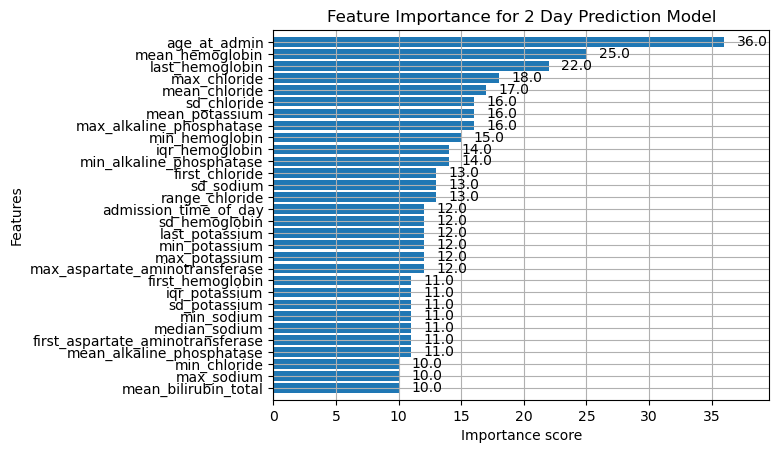

In [39]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(XGB_model_2, max_num_features=30, height=0.8)
plt.title('Feature Importance for 2 Day Prediction Model') 
plt.show()

In [40]:
XGB_model_2.save_model('unimpute_2d_best_model.json')

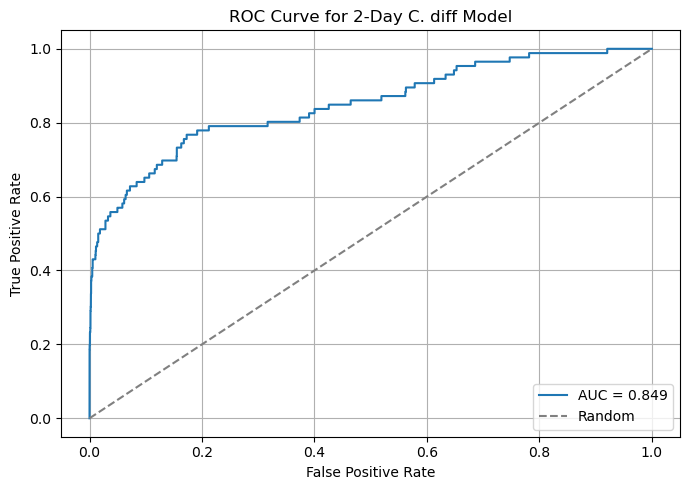

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Ground truth (30-day flag)
y_val_2 = val_df["cdiff_2d_flag"]

# Predicted probabilities from your model (positive class only)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_val_2, y_val_prob_2)
auc_score = roc_auc_score(y_val_2, y_val_prob_2)

# Plot
plt.figure(figsize=(7, 5))
plt.step(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for 2-Day C. diff Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

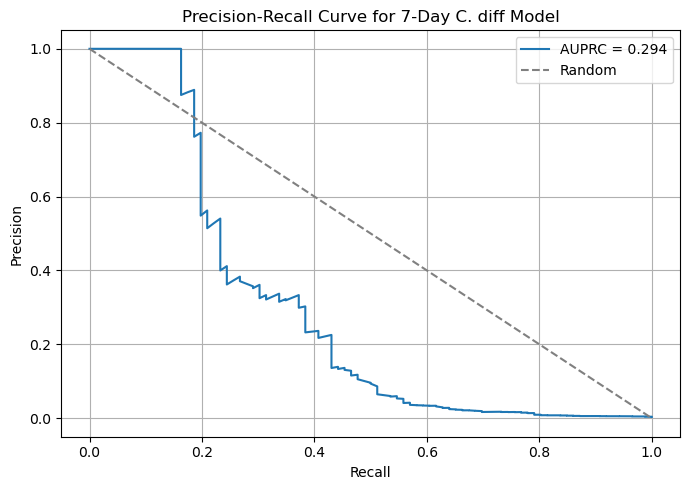

In [42]:
# Ground truth labels
y_val_2 = val_df["cdiff_2d_flag"]

# Predicted probabilities (positive class)
y_val_prob_2 = XGB_model_2.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_val_2, y_val_prob_2)

# Compute area under the precision-recall curve (AUPRC)
auprc_score = average_precision_score(y_val_2, y_val_prob_2)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AUPRC = {auprc_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [1, 0], linestyle='--', color='gray', label="Random")
plt.title("Precision-Recall Curve for 7-Day C. diff Model")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, average_precision_score
from matplotlib.lines import Line2D

windows = ['2d', '7d', '30d']
colors = ['steelblue', 'darkorchid', 'firebrick']
plt.figure(figsize=(10, 8))
plt.style.use('bmh')

custom_lines = []

for i, window in enumerate(windows):
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f'unimpute_{window}_best_model.json')
    y_true = val_df[f'cdiff_{window}_flag']
    y_val_prob = xgb_model.predict_proba(X_val)[:, 1]

    precision, recall, _ = precision_recall_curve(y_true, y_val_prob)
    ap_score = average_precision_score(y_true, y_val_prob)

    plt.step(recall, precision, where='post', color=colors[i])
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=2, label=f'{window} AUPRC = {ap_score:.3f}'))

    prevalence = y_true.mean()
    plt.hlines(prevalence, 0, 1, linestyle='--', color=colors[i], alpha=0.5)
    custom_lines.append(Line2D([0], [0], color=colors[i], lw=1, linestyle='--', alpha=0.5, label=f'No-Skill: {window}'))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for C. diff Prediction Windows in Validation Set")
plt.legend(handles=custom_lines, loc="lower left")
plt.tight_layout()
plt.show()


/project/bios26406/conda/ml4h/lib/python3.13/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


NameError: name 'val_df' is not defined

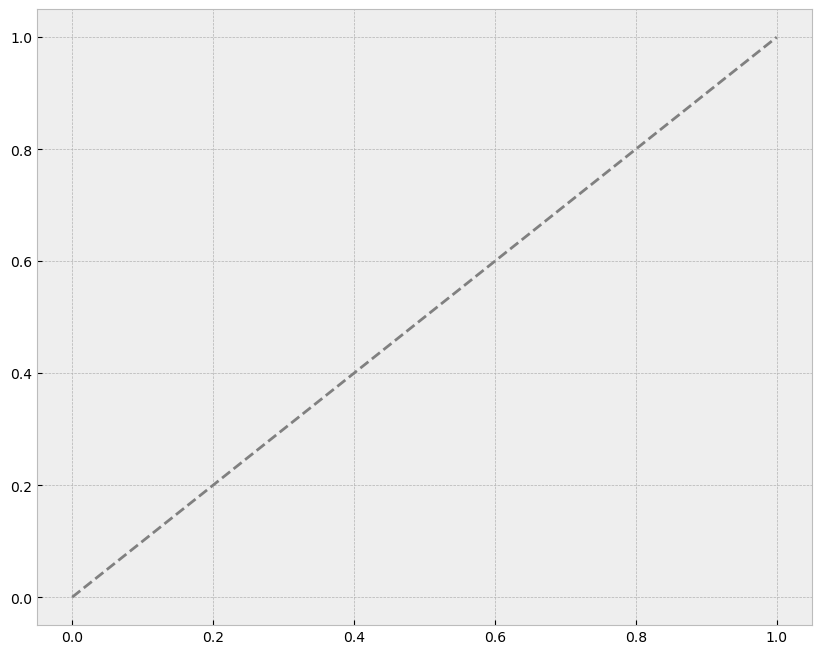

In [1]:
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import roc_curve, roc_auc_score

windows = ['2d', '7d', '30d']
colors = ['steelblue', 'darkorchid', 'firebrick']

plt.figure(figsize=(10, 8))
plt.style.use('bmh')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No Skill')

for i, window in enumerate(windows):
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f'unimpute_{window}_best_model.json')
    y_true = val_df[f'cdiff_{window}_flag']
    y_val_prob = xgb_model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_val_prob)
    auc = roc_auc_score(y_true, y_val_prob)

    plt.plot(fpr, tpr, color=colors[i], label=f'{window} AUROC = {auc:.3f}')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for C. diff Prediction Windows in Validation Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


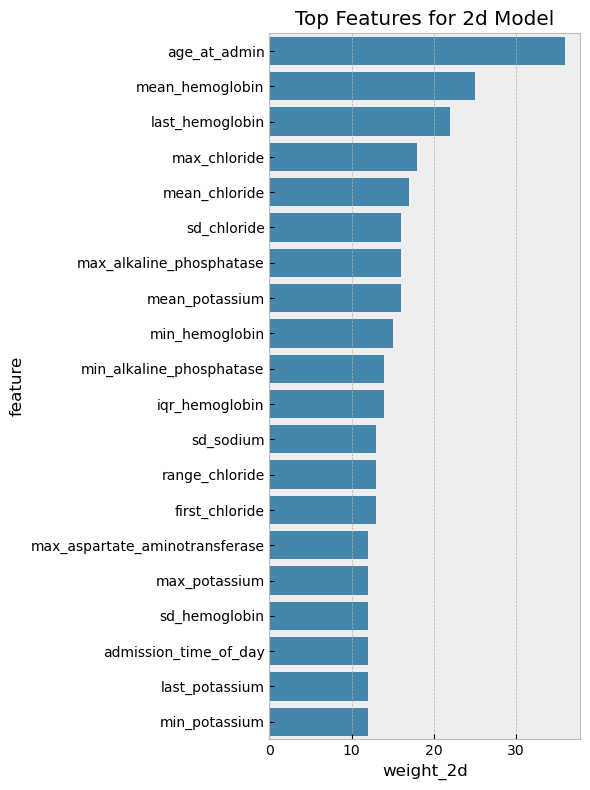

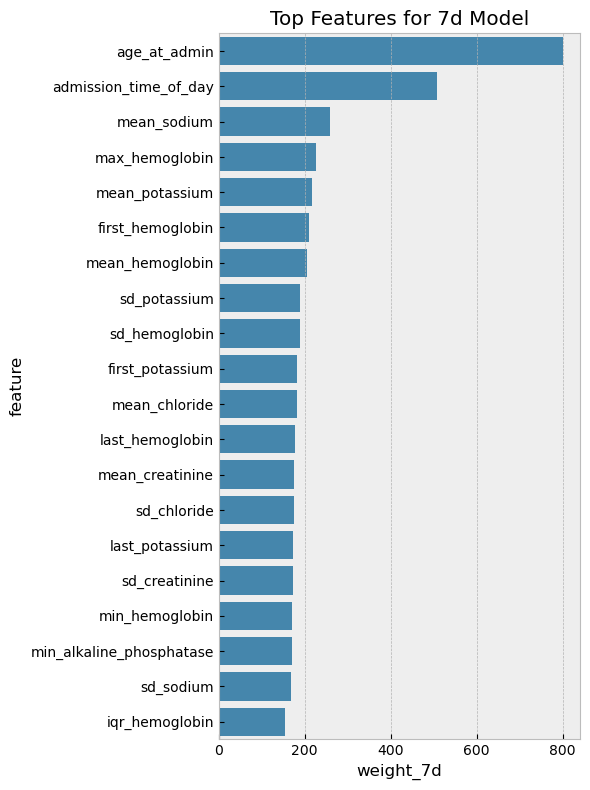

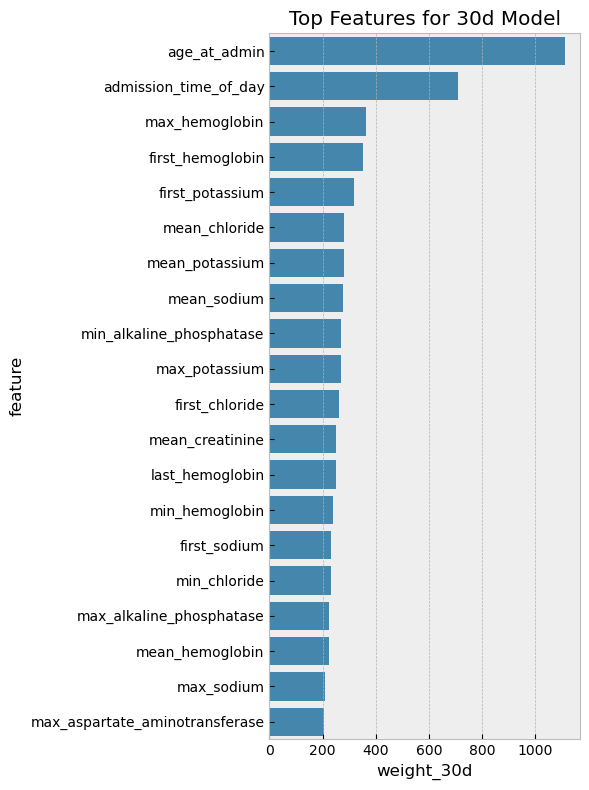

In [27]:
import seaborn as sns
windows = ['2d', '7d', '30d']
feature_importances_df = pd.DataFrame({'feature': xgb_model.feature_names_in_})
# plt.figure(figsize=(10, 7))
# plt.style.use('bmh')
for window in windows:
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f'unimpute_{window}_best_model.json')

    window_df = pd.DataFrame(xgb_model.get_booster().get_score(importance_type='weight').items(), columns=['feature', f'weight_{window}']).sort_values([f'weight_{window}'], ascending=False).head(20)

    plt.figure(figsize=(6, 8))
    plt.style.use('bmh')
    sns.barplot(window_df, y = 'feature', x = f'weight_{window}')
    plt.title(f'Top Features for {window} Model')
    plt.tight_layout()
    plt.show()

# feature_importances_long = pd.melt(feature_importances_df, id_vars=['feature'], value_vars=['weight_2d', 'weight_7d', 'weight_30d'])
# feature_importances_long = feature_importances_long.sort_values(['value'], ascending=False).head(30)
# g.set_xticklabels(g.get_xticklabels(), rotation=45)
# g.despine(left=True)
# g.set_axis_labels("Window", "Feature importance")
# g.legend.set_title("")